# Projeto Ponta a Ponta: Construindo um Modelo de Detecção de Incêndios com o Kaggle FIRE Database

- Este notebook detalha a construção de um modelo de Inteligência Artificial capaz de detectar a presença de fogo em imagens. O objetivo é desenvolver uma ferramenta que possa analisar qualquer imagem e identificar se há indícios de incêndio.

### Dataset Utilizado
- Para o treinamento, utilizaremos o **FIRE Database** do Kaggle, disponível em: [FIRE-MAC Dataset](https://www.kaggle.com/datasets/phylake1337/fire-dataset). Este dataset é composto por 999 imagens, categorizadas em 'fogo' e 'não-fogo', que servirão como base para o aprendizado do modelo após um processo de tratamento e pré-processamento.

# Imports


In [1]:
# Versão da Linguagem Python
from platform import python_version
print('Versão do Python neste Notebook:', python_version())

Versão do Python neste Notebook: 3.12.13


In [2]:
# Instala o TF
#!pip install -q tensorflow==2.12
!pip install -q tensorflow

In [3]:
# Silencia mensagens do TF
%env TF_CPP_MIN_LOG_LEVEL=3

env: TF_CPP_MIN_LOG_LEVEL=3


In [4]:
# Imports
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from PIL import Image
import kagglehub
from pathlib import Path
import cv2
import requests
from io import BytesIO

## Carregando e Tratando os Dados: Preparação da Matéria-Prima

- Nesta seção, realizamos o download e o tratamento inicial do dataset. As imagens são carregadas, redimensionadas e convertidas para o formato adequado, garantindo que os dados estejam prontos para o treinamento do modelo.

In [5]:
# Download latest version
path = kagglehub.dataset_download("phylake1337/fire-dataset")

print("Path to dataset files:", path)

100%|██████████| 387M/387M [00:04<00:00, 96.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/phylake1337/fire-dataset/versions/1


In [6]:
# Configurações iniciais
caminho = Path(path) / 'fire_dataset' # Ajustado para apontar para a pasta correta
tamanho_imagem = (32, 32) # Redimensiona para o tamanho esperado pelo modelo

lista_imagens = []
lista_labels = []

# Passa por todas as imagens dentro da pasta e subpastas
for arquivo in caminho.rglob('*.*'):
    # Pega o caminho como texto em minúsculo
    caminho_str = str(arquivo).lower()

    # Verifica se é realmente uma imagem
    if arquivo.suffix.lower() in ['.jpg', '.jpeg', '.png']:

        # 1. Define o label (0 para non-fire, 1 para fire)
        if 'non_fire' in caminho_str:
            label = 0
        elif 'fire_images' in caminho_str:
            label = 1
        else:
            continue # Pula o arquivo se não tiver a palavra no nome

        # 2. Carrega a imagem com OpenCV
        img = cv2.imread(str(arquivo))

        if img is not None:
            # CONVERSÃO: OpenCV (BGR) -> Matplotlib/Modelo (RGB)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # 3. Redimensiona a imagem e adiciona nas listas
            img_redimensionada = cv2.resize(img, tamanho_imagem)
            lista_imagens.append(img_redimensionada)
            lista_labels.append(label)

# 4. Transforma as listas em arrays do NumPy (X para imagens, y para labels)
X = np.array(lista_imagens)
y = np.array(lista_labels).reshape(-1, 1) # Reshape para (N, 1) para consistência

print(f"Total de imagens carregadas (X): {X.shape[0]}")
print(f"Total de imagens 'non-fire' (0): {np.count_nonzero(y == 0)}")
print(f"Total de imagens 'fire' (1): {np.count_nonzero(y == 1)}")

Total de imagens carregadas (X): 999
Total de imagens 'non-fire' (0): 244
Total de imagens 'fire' (1): 755


In [7]:
# Classes das imagens
nomes_classes = ['non-fire', 'fire']

In [8]:
from sklearn.model_selection import train_test_split

# Identifica os índices de cada classe
indices_0 = np.where(y == 0)[0]
indices_1 = np.where(y == 1)[0]

# Define a quantidade mínima entre as duas classes para equilibrar
n_amostras = min(len(indices_0), len(indices_1))

# Seleciona aleatoriamente a mesma quantidade de cada classe
np.random.seed(42)
indices_0_equilibrados = np.random.choice(indices_0, n_amostras, replace=False)
indices_1_equilibrados = np.random.choice(indices_1, n_amostras, replace=False)

# Une os índices e filtra o dataset original
indices_finais = np.concatenate([indices_0_equilibrados, indices_1_equilibrados])
X_bal = X[indices_finais]
y_bal = y[indices_finais]

# Divide os dados equilibrados em conjuntos de treino e teste (80/20)
imagens_treino, imagens_teste, labels_treino, labels_teste = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal
)

print(f"Total equilibrado: {X_bal.shape[0]} imagens")
print(f"Imagens de treino: {imagens_treino.shape[0]}")
print(f"Imagens de teste: {imagens_teste.shape[0]}")
print(f"Distribuição no teste: {np.bincount(labels_teste.flatten())}")

Total equilibrado: 488 imagens
Imagens de treino: 390
Imagens de teste: 98
Distribuição no teste: [49 49]


In [9]:
# Normaliza os valores dos pixels para que os dados fiquem na mesma escala (0 a 1)
imagens_treino = imagens_treino / 255.0
imagens_teste = imagens_teste / 255.0

In [10]:
# Função para exibir as imagens
def visualiza_imagens(images, labels):
    plt.figure(figsize = (10,10))
    for i in range(25):
        plt.subplot(5, 5, i+1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(images[i], cmap = plt.cm.binary)
        plt.xlabel(nomes_classes[labels[i][0]])
    plt.show()

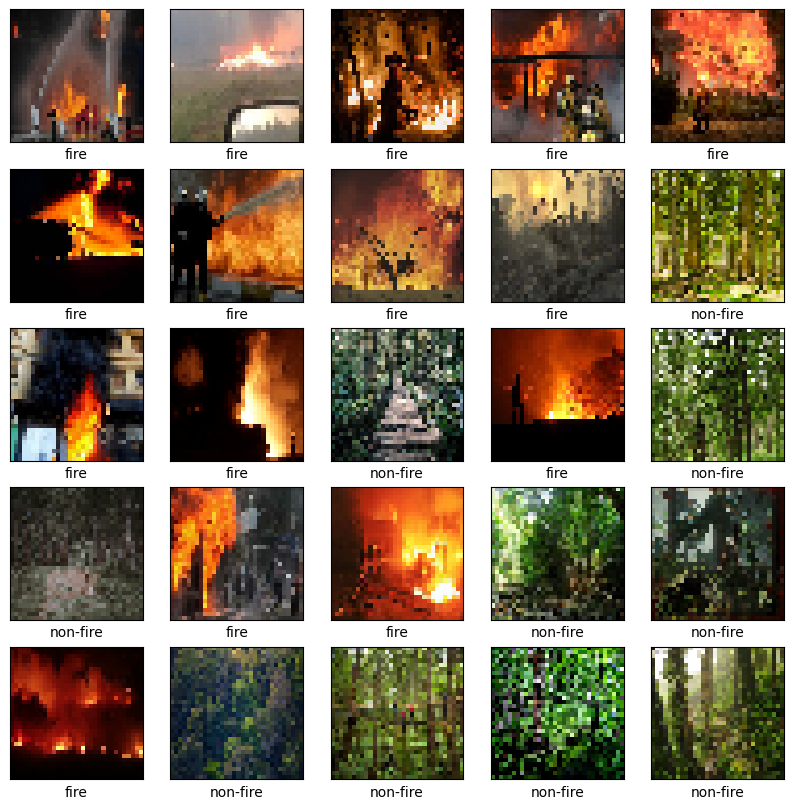

In [11]:
# Executa a função
visualiza_imagens(imagens_treino, labels_treino)

# Construção do Modelo
O processo de construção do modelo consiste em:
- **Arquitetura:** Camadas convolucionais (Conv2D) extraem características visuais e pooling reduz a resolução;
- **Classificação:** Camadas densas transformam os padrões em decisões lógicas;
- **Compilação:** O otimizador Adam e a função de perda ajustam os erros;
- **Treinamento:** O modelo aprende ao longo de 15 épocas validando os resultados em tempo real.

In [12]:
# Arquitetura do Modelo -> Feature Learning

from tensorflow.keras import models, layers

modelo_lia = models.Sequential()

# Camada de entrada
modelo_lia.add(layers.Input(shape=(32, 32, 3)))

# Blocos convolucionais + pooling
modelo_lia.add(layers.Conv2D(32, (3, 3), activation='relu'))
modelo_lia.add(layers.MaxPooling2D((2, 2)))

modelo_lia.add(layers.Conv2D(64, (3, 3), activation='relu'))
modelo_lia.add(layers.MaxPooling2D((2, 2)))

modelo_lia.add(layers.Conv2D(64, (3, 3), activation='relu'))
modelo_lia.add(layers.MaxPooling2D((2, 2)))

In [13]:
# Adicionar camadas de classificação - Converte para um vetor - flatten
modelo_lia.add(layers.Flatten())
modelo_lia.add(layers.Dense(64, activation = 'relu'))
modelo_lia.add(layers.Dense(2, activation = 'softmax')) # Alterado para 2 classes

In [14]:
# Sumário do modelo
modelo_lia.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,898 (284.76 KB)

 Trainable params: 72,898 (284.76 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Compilação do modelo
modelo_lia.compile(optimizer = 'adam',
                   loss = 'sparse_categorical_crossentropy',
                   metrics = ['accuracy'])

# adam - é um algoritmo de aprendizagem tipo backpropagation!
# loss - função de erro. Isso se resume a uma otimização função matemática!
# metrics - medir o sucesso!

In [16]:
%%time
history = modelo_lia.fit(imagens_treino,
                         labels_treino,
                         epochs = 15,
                         validation_data = (imagens_teste, labels_teste))


Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.7718 - loss: 0.5397 - val_accuracy: 0.7959 - val_loss: 0.4728
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.8564 - loss: 0.3518 - val_accuracy: 0.8673 - val_loss: 0.2619
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.9103 - loss: 0.2743 - val_accuracy: 0.8776 - val_loss: 0.2509
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.9231 - loss: 0.2116 - val_accuracy: 0.9388 - val_loss: 0.1604
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.9308 - loss: 0.1870 - val_accuracy: 0.9388 - val_loss: 0.1381
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.9256 - loss: 0.1659 - val_accuracy: 0.9592 - val_loss: 0.1288
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.9538 - loss: 0.1263 - val_accuracy: 0.9490 - val_loss: 0.0927
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.9564 - loss: 0.1102 - val_accuracy: 0.9490 - v

# Avaliação do Modelo: Diagnóstico e Performance
A etapa de avaliação consiste em:
- **Métricas Globais:** Cálculo da acurácia e erro (loss) utilizando o conjunto de teste inédito;
- **Matriz de Confusão:** Cruzamento entre previsões e valores reais para identificar falsos positivos e negativos;
- **Visualização de Erros:** Geração de mapas de calor (heatmaps) para facilitar a interpretação estatística;
- **Validação Final:** Confirmação da capacidade de generalização do modelo para ambientes de produção.

In [17]:
# Avalia o modelo
erro_teste, acc_teste = modelo_lia.evaluate(imagens_teste, labels_teste, verbose = 2)


4/4 - 0s - 20ms/step - accuracy: 0.9694 - loss: 0.0910


In [18]:
# Avalia o modelo
erro_teste, acc_teste = modelo_lia.evaluate(imagens_teste, labels_teste, verbose = 2)

print('\nAcurácia com dados de Teste:', acc_teste)

4/4 - 0s - 19ms/step - accuracy: 0.9694 - loss: 0.0910

Acurácia com dados de Teste: 0.9693877696990967


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


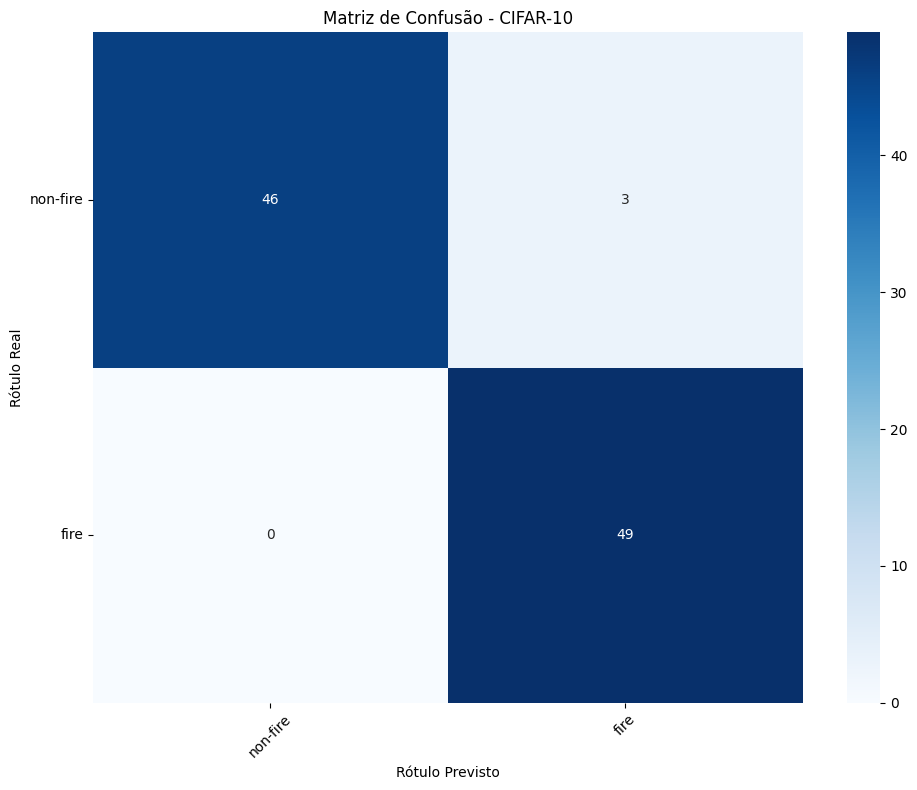

In [19]:
# Imprime a matriz de confusão
from sklearn.metrics import confusion_matrix

# Previsão do modelo
y_pred = modelo_lia.predict(imagens_teste)
y_pred_classes = np.argmax(y_pred, axis=1)

# Labels já estão no formato inteiro, então podemos usá-las diretamente
y_true = labels_teste.flatten()  # Caso labels_teste tenha shape (10000, 1)

# Geração da matriz de confusão
cm = confusion_matrix(y_true, y_pred_classes)

# Impressão
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nomes_classes,
            yticklabels=nomes_classes)
plt.title('Matriz de Confusão - CIFAR-10')
plt.xlabel('Rótulo Previsto')
plt.ylabel('Rótulo Real')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Deploy e Inferência
A etapa de deploy consiste em:
- **Captura de Dados:** Download de uma imagem inédita via URL e conversão para formato digital;
- **Pré-processamento:** Redimensionamento e normalização para compatibilidade com o modelo treinado;
- **Predição Neural:** Execução da inferência para obter as probabilidades de cada classe;
- **Resultado Final:** Tradução numérica das probabilidades em uma classificação legível de 'fogo' ou 'não-fogo'.

In [20]:
# Insira a URL da imagem aqui
url_da_imagem = "https://i.pinimg.com/474x/f9/7a/61/f97a6146f74096f19927e9a0148319aa.jpg"

# Carrega a imagem via URL
response = requests.get(url_da_imagem)
nova_imagem = Image.open(BytesIO(response.content))

A largura da imagem é:  400
A altura da imagem é:  533


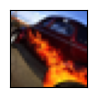

In [21]:
# Obtém largura e altura da imagem
largura = nova_imagem.width
altura = nova_imagem.height

print("A largura da imagem é: ", largura)
print("A altura da imagem é: ", altura)

# Redimensiona para 32x32 pixels
nova_imagem = nova_imagem.resize((32, 32))

# Exibir a imagem
plt.figure(figsize = (1,1))
plt.imshow(nova_imagem)
plt.xticks([])
plt.yticks([])
plt.show()

In [22]:
# Converte a imagem para um array NumPy e normaliza
nova_imagem_array = np.array(nova_imagem) / 255.0

# Expande a dimensão do array para que ele tenha o formato (1, 32, 32, 3)
nova_imagem_array = np.expand_dims(nova_imagem_array, axis = 0)

# Previsões
previsoes = modelo_lia.predict(nova_imagem_array)
print(previsoes)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
[[5.1471456e-05 9.9994850e-01]]


In [23]:
# Obtém a classe com maior probabilidade e o nome da classe
classe_prevista = np.argmax(previsoes)
nome_classe_prevista = nomes_classes[classe_prevista]

print("A nova imagem foi classificada como:", nome_classe_prevista)


A nova imagem foi classificada como: fire


# Conclusão do Projeto

Este projeto demonstrou a construção de um modelo de Inteligência Artificial para detecção de incêndios. O dataset foi importado, tratado e o modelo foi treinado com sucesso, alcançando um nível de acurácia satisfatório nos dados de teste.

### Pontos Observados:

*   **Eficiência em Casos Extremos:** O modelo se mostrou altamente eficiente na detecção de imagens com presença clara de fogo ou ausência total dele.
*   **Desafio em Cenários Intermediários:** Em situações com indícios sutis ou intermediários de fogo, onde a distinção não é tão evidente, a eficácia do modelo pode ser ligeiramente reduzida, indicando uma área para futuras otimizações.

### Impacto e Aplicações

Apesar da sua simplicidade, este modelo serve como uma prova de conceito robusta, ilustrando o potencial da visão computacional na resolução de problemas do mundo real, como a detecção precoce de incêndios. As futuras iterações poderiam explorar arquiteturas mais complexas e técnicas de aumento de dados para aprimorar ainda mais sua performance em cenários desafiadores.